### Phase 1: Understanding Recommender Systems


پرسش اول:
در سیستم پیشنهادی مبتنی بر کاربر ،سیستم بر اساس علاقه افرادی که سیلقه مشابه با فرد مورد نظر دارد،چیزی را پیشنهاد میدهد ولی در سیستم پیشنهادی مبتنی بر ایتم ، سیستم ایتم هایی را پیشنهاد میدهد که کاربر ایتم های مشابه آن را دوست داشته است..برای مثال کاربری در یک پلت فرمی مثل فیلیمو به یک فیلم طنز امتیاز بالا میدهد و سیستم به او سایر فیلم های طنز را پیشنهاد میدهد.


پرسش دوم:شباهت کسینوسی یک معیار برای اندازه‌گیری شباهت بین دو بردار است که بر اساس زاویه بین آن‌ها محاسبه می‌شود. این معیار به جای فاصله، به زاویه بین دو بردار توجه می‌کند. اگر زاویه بین دو بردار صفر باشد، شباهت کسینوسی برابر با ۱ خواهد بود که نشان‌دهنده شباهت کامل است. اگر زاویه ۹۰ درجه باشد، شباهت کسینوسی صفر خواهد بود که نشان‌دهنده عدم شباهت است.



برای اندازه گیری این شباهت از رابطه زیر استفاده میکنیم که ضرب داخلی دو بردار را تقسیم بر ضرب نرم آن دو بردار میکینم:







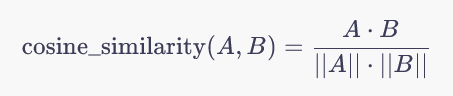

در سیستم پیشنهادی که قرار است به کاربر بدهیم از این تکنیک استفاده میکنم به صورتی که دیتا های مورد نطرمون به شکل وکتور یا همان بردار هستند و با شباهت سنجی میان دو بردار میتوانیم علایق کاربران را مقایسه کنیم و بهترین مورد را پیشنهاد بدهیم

### Phase 2: Data Preprocessing

In [85]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
df = pd.read_csv('ratings.csv')
print(df.iloc[:10],end='\n\n')
print(df.info())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
5       1       70     3.0  964982400
6       1      101     5.0  964980868
7       1      110     4.0  964982176
8       1      151     5.0  964984041
9       1      157     5.0  964984100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None


In [86]:
df.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [87]:
scaler=MinMaxScaler()
df['rating']=scaler.fit_transform(df[['rating']])
df.iloc[:30]

,userId,movieId,rating,timestamp
0,1,1,0.777778,964982703
1,1,3,0.777778,964981247
2,1,6,0.777778,964982224
3,1,47,1.000000,964983815
4,1,50,1.000000,964982931
5,1,70,0.555556,964982400
6,1,101,1.000000,964980868
7,1,110,0.777778,964982176
8,1,151,1.000000,964984041
9,1,157,1.000000,964984100


### Phase 3: Model Development

In [88]:
from sklearn.model_selection import train_test_split

X=df.drop('rating',axis=1)
y=df['rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print(X_train.shape)
print(X_test.shape)

print(df['rating'].min())

(80668, 3)
(20168, 3)
0.0


In [75]:
!pip install scikit-surprise


### Phase 4: Model Evaluation

In [95]:
from surprise import Dataset, Reader
from surprise import KNNBasic
from surprise import accuracy
from surprise.model_selection import train_test_split
# Define the Reader with the MinMaxscaling raiting
reader = Reader(rating_scale=(0, 1))
df['rating']=df['rating']+0.000000001

data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2)
sim_options = {
    'name': 'cosine',
    'user_based': True  # Compute similarities between users, now items!
}
model = KNNBasic(sim_options=sim_options)
model.fit(trainset)

predictions = model.test(testset)
for prediction in predictions[10:30]:
    print(prediction)


Computing the cosine similarity matrix...
Done computing similarity matrix.
user: 119        item: 3793       r_ui = 0.78   est = 0.79   {'actual_k': 40, 'was_impossible': False}
user: 438        item: 5507       r_ui = 0.56   est = 0.51   {'actual_k': 19, 'was_impossible': False}
user: 113        item: 1244       r_ui = 0.78   est = 0.80   {'actual_k': 27, 'was_impossible': False}
user: 387        item: 8228       r_ui = 0.78   est = 0.75   {'actual_k': 12, 'was_impossible': False}
user: 414        item: 8860       r_ui = 0.56   est = 0.51   {'actual_k': 5, 'was_impossible': False}
user: 318        item: 71464      r_ui = 0.78   est = 0.60   {'actual_k': 10, 'was_impossible': False}
user: 202        item: 1625       r_ui = 0.56   est = 0.77   {'actual_k': 40, 'was_impossible': False}
user: 72         item: 356        r_ui = 0.78   est = 0.82   {'actual_k': 40, 'was_impossible': False}
user: 414        item: 2541       r_ui = 0.33   est = 0.61   {'actual_k': 34, 'was_impossible': False

In [98]:

rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)


RMSE: 0.2147
MAE:  0.1654


In [99]:
for i, prediction in enumerate(predictions[:100]):
    print(f'User: {prediction.uid}, Item: {prediction.iid}, Actual: {prediction.r_ui}, Predicted: {prediction.est}')

User: 98, Item: 69644, Actual: 0.2222222252222222, Predicted: 0.4472542269646837
User: 119, Item: 7454, Actual: 0.6666666696666664, Predicted: 0.5311665452247936
User: 39, Item: 3000, Actual: 1.0000000030000002, Predicted: 0.7483486352193975
User: 604, Item: 593, Actual: 1.0000000030000002, Predicted: 0.8248519620621406
User: 374, Item: 110, Actual: 1.0000000030000002, Predicted: 0.8030228892532772
User: 477, Item: 1208, Actual: 1.0000000030000002, Predicted: 0.8778211483260724
User: 153, Item: 8784, Actual: 0.8888888918888888, Predicted: 0.6992036421833568
User: 599, Item: 136562, Actual: 0.6666666696666664, Predicted: 0.6671735910774502
User: 89, Item: 33646, Actual: 0.5555555585555555, Predicted: 0.5436264709243296
User: 105, Item: 112290, Actual: 0.7777777807777776, Predicted: 0.681563738329794
User: 119, Item: 3793, Actual: 0.7777777807777776, Predicted: 0.7887442606480967
User: 438, Item: 5507, Actual: 0.5555555585555555, Predicted: 0.510576804822833
User: 113, Item: 1244, Actual

In [103]:
#Baseline model
from surprise import BaselineOnly
from surprise import accuracy


baseline_model = BaselineOnly()
baseline_model.fit(trainset)


baseline_predictions = baseline_model.test(testset)
baseline_rmse = accuracy.rmse(baseline_predictions)
baseline_mae = accuracy.mae(baseline_predictions)



Estimating biases using als...
RMSE: 0.1929
MAE:  0.1485


In [ ]:
# baseline was better than knn :(

### Phase 5: Conclusion

از مزایای این مدل این است که در داده های کم تر عملکرد بهتری نسبتا دارد.و مدل عملکرد خوبی دارد ولی این مدل در داده های بالا میتواند هزینه محاسباتی زیادی داشته باشد زیرا باید تمامی شباهت های کاربران و ایتم ها را بررسی کند


برای بهتر کردن الگوریتم میتوانیم از سایر شباهت ها در کنار شباهت کسینوسی استفاده کنیم مانند شباهت پیرسی یا اقلیدسی
همچنین استفاده از هایپرپارامتر های بهینه میتواند در بهبود عملکرد الگوریتم کمک شایانی داشته باشد